# Correlations - comparison between ELAsTiCC and pseudo-observations

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

## Open ELAsTiCC data correlations
They were calculated previously and are loaded in several steps to avoid a kernel crash...

In [3]:
file_open = open('../data/elasticc/data_no_periodic.pkl', 'rb')
df_no_periodic = pickle.load(file_open)
file_open.close()

In [4]:
file_open = open('../data/elasticc/features_periodic_2322_2323.pkl', 'rb')
df_periodic_1 = pickle.load(file_open)
file_open.close()

In [5]:
file_open = open('../data/elasticc/features_periodic_2324_2325.pkl', 'rb')
df_periodic_2 = pickle.load(file_open)
file_open.close()

In [6]:
df_elasticc = pd.concat([df_no_periodic, df_periodic_1, df_periodic_2], ignore_index=True)
df_elasticc['type'] = 'elasticc'
pdf_elasticc = df_elasticc.drop(['alertId', 'cpsFlux', 'cpsFluxErr', 'mags', 'time', 'mags_lim', 'filt', 'mags_err'], axis=1)

In [7]:
len(pdf_elasticc)

2112694

## Open pseudo-observation correlations

In [8]:
file_open = open('../data/pseudo_obs/features_pseudo_obs.pkl', 'rb')
df_po = pickle.load(file_open)
file_open.close()

In [9]:
df_po['type'] = 'pseudo-obs'
pdf_po = df_po.drop(['config', 'grb_time', 'grb_coord', 'time', 'mags', 'filt', 'mags_lim', 'mags_err'], axis=1)

In [10]:
len(pdf_po)

241678

## Gathering all the correlations into one DataFrame

In [11]:
pdf = pd.concat([pdf_elasticc, pdf_po], ignore_index=True)

In [12]:
pdf

,mag_peak,first_detect,time_peak,color,rate_dec_1,rate_dec_3,rate_inc,dt,type
0,21.967399,60275.137400,NaN,NaN,NaN,NaN,NaN,NaN,elasticc
1,21.594604,60278.032200,NaN,NaN,NaN,NaN,NaN,NaN,elasticc
2,21.594604,60278.032200,NaN,NaN,NaN,NaN,NaN,NaN,elasticc
3,22.610292,60275.146500,NaN,NaN,NaN,NaN,NaN,NaN,elasticc
4,22.940764,60276.205500,NaN,NaN,NaN,NaN,NaN,NaN,elasticc
...,...,...,...,...,...,...,...,...,...
2354367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pseudo-obs
2354368,21.390305,63546.349055,63546.362341,0.179629,NaN,NaN,NaN,0.000000,pseudo-obs
2354369,20.757785,60998.218882,61139.021560,NaN,NaN,NaN,-0.010760,72.024256,pseudo-obs
2354370,21.697711,61751.343813,61835.166034,0.316336,0.000072,0.00183,-0.004842,39.441263,pseudo-obs


## Cut g-r color < 0 or > 0.5 mag

In [13]:
pdf_cut_color = pdf[(pdf['color'] > 0.1) & (pdf['color'] < 0.4)]

In [14]:
# percentage of left events in elasticc data
len(pdf_cut_color[pdf_cut_color['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['color'])) * 100

17.677691408829954

In [15]:
# percentage of left events in pseudo-observations
len(pdf_cut_color[pdf_cut_color['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['color'])) * 100

97.30701353029609

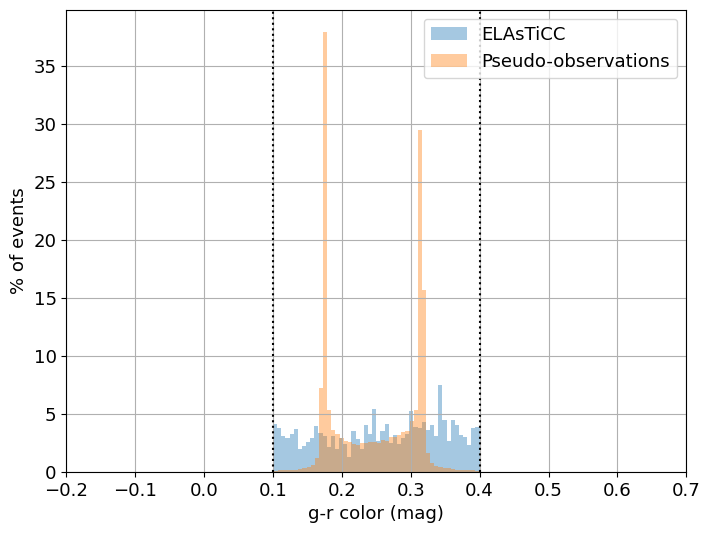

In [16]:
plt.rcParams.update({'font.size': 13})
plt.figure(figsize=(8, 6))

pdf_cut_color['color'][pdf_cut_color['type'] == 'elasticc'].hist(bins=50, alpha=0.4, label='ELAsTiCC', density=True);
pdf_cut_color['color'][pdf_cut_color['type'] == 'pseudo-obs'].hist(bins=50, alpha=0.4, label='Pseudo-observations', density=True);

plt.xlabel('g-r color (mag)')
plt.ylabel('% of events')
plt.xlim(-0.2, 0.7)
plt.axvline(x=0.1, color='k', ls=':')
plt.axvline(x=0.4, color='k', ls=':')
plt.legend()

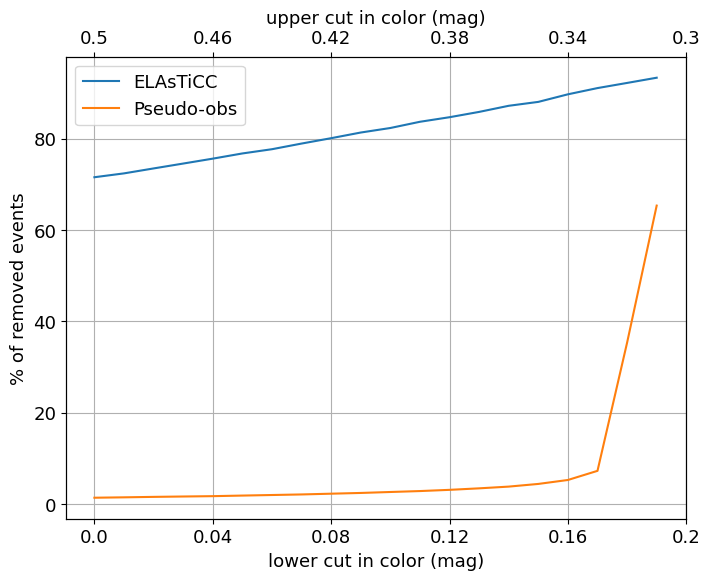

In [17]:
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)
ax2 = ax1.twiny()

cut_inf = np.arange(0., 0.2, 0.01)
cut_sup = np.arange(0.5, 0.3, -0.01)

elasticc = []
po = []

for i, j in zip(cut_inf, cut_sup):
    
    pdf_cut_color = pdf[(pdf['color'] > i) & (pdf['color'] < j)]
    elasticc.append(len(pdf_cut_color[pdf_cut_color['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['color'])))
    po.append(len(pdf_cut_color[pdf_cut_color['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['color'])))

ax1.plot(cut_inf, (1-np.array(elasticc))*100, label='ELAsTiCC')
ax1.plot(cut_inf, (1-np.array(po))*100, label='Pseudo-obs')

ax1.set_ylabel('% of removed events')
ax1.set_xlabel('lower cut in color (mag)')
ax1.set_xticks([0.0, 0.04, 0.08, 0.12, 0.16, 0.2], labels=[0.0, 0.04, 0.08, 0.12, 0.16, 0.2])

ax2.set_xlabel('upper cut in color (mag)')
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks([0.0, 0.04, 0.08, 0.12, 0.16, 0.2], labels=[0.5, 0.46, 0.42, 0.38, 0.34, 0.3])

ax1.legend()
ax1.grid()

## Cut decrease rate 3/3 > 0.4 mag/day

In [18]:
pdf_cut_d3 = pdf[(pdf['rate_dec_3'] < 0.15)]

In [19]:
# percentage of left events in elasticc data
len(pdf_cut_d3[pdf_cut_d3['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['rate_dec_3'])) *100

68.37516909664812

In [20]:
# percentage of left events in pseudo-observations
len(pdf_cut_d3[pdf_cut_d3['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['rate_dec_3'])) *100

99.67895709699387

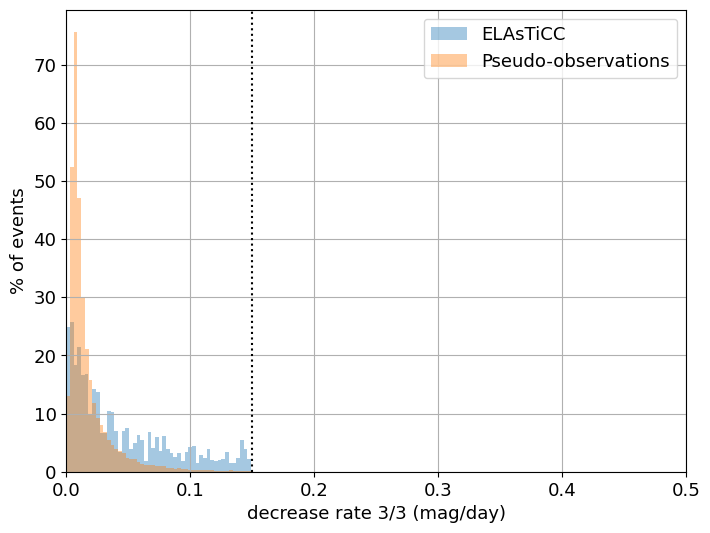

In [21]:
plt.figure(figsize=(8, 6))

pdf_cut_d3['rate_dec_3'][pdf_cut_d3['type'] == 'elasticc'].hist(bins=50, alpha=0.4, label='ELAsTiCC', density=True);
pdf_cut_d3['rate_dec_3'][pdf_cut_d3['type'] == 'pseudo-obs'].hist(bins=50, alpha=0.4, label='Pseudo-observations', density=True);

plt.xlabel('decrease rate 3/3 (mag/day)')
plt.ylabel('% of events')
plt.xlim(0, 0.5)
plt.axvline(x=0.15, color='k', ls=':')
plt.legend()

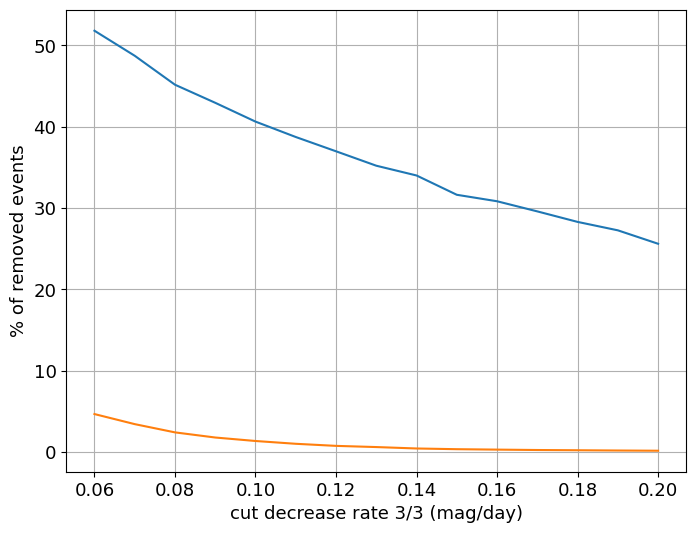

In [22]:
plt.figure(figsize=(8, 6))

cut = np.arange(0.06, 0.2, 0.01)

elasticc = []
po = []

for i in cut:
    
    pdf_cut_d3 = pdf[(pdf['rate_dec_3'] < i)]
    elasticc.append(len(pdf_cut_d3[pdf_cut_d3['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['rate_dec_3'])))
    po.append(len(pdf_cut_d3[pdf_cut_d3['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['rate_dec_3'])))
    
plt.plot(cut, (1-np.array(elasticc))*100, label='ELAsTiCC')
plt.plot(cut, (1-np.array(po))*100, label='Pseudo-observations')
plt.xlabel('cut decrease rate 3/3 (mag/day)')
plt.ylabel('% of removed events')
plt.grid()

## Cut increase rate < -0.25 mag/day

In [23]:
pdf_cut_i = pdf[(pdf['rate_inc'] > -0.3)]

In [24]:
# percentage of left events in elasticc data
len(pdf_cut_i[pdf_cut_i['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['rate_inc'])) * 100

83.62077911296515

In [25]:
# percentage of left events in pseudo-observations
len(pdf_cut_i[pdf_cut_i['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['rate_inc'])) * 100

95.88035892323032

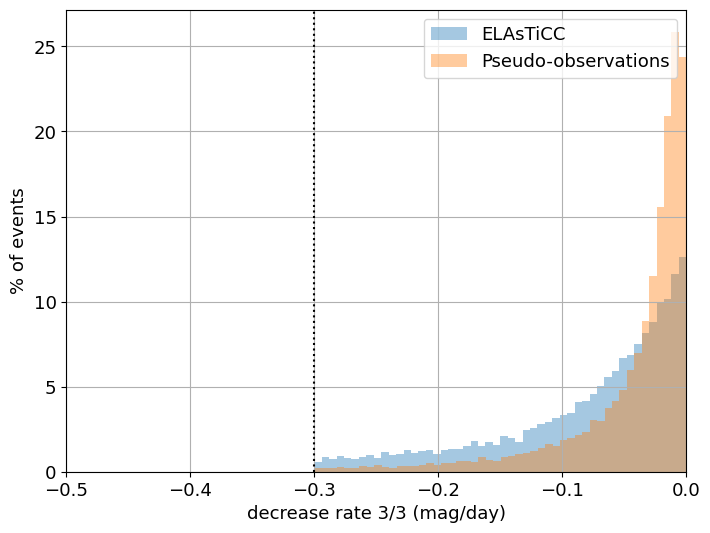

In [26]:
plt.figure(figsize=(8, 6))

pdf_cut_i['rate_inc'][pdf_cut_i['type'] == 'elasticc'].hist(bins=50, alpha=0.4, label='ELAsTiCC', density=True);
pdf_cut_i['rate_inc'][pdf_cut_i['type'] == 'pseudo-obs'].hist(bins=50, alpha=0.4, label='Pseudo-observations', density=True);

plt.xlabel('decrease rate 3/3 (mag/day)')
plt.ylabel('% of events')
plt.xlim(-0.5, 0.)
plt.axvline(x=-0.3, color='k', ls=':')
plt.legend()

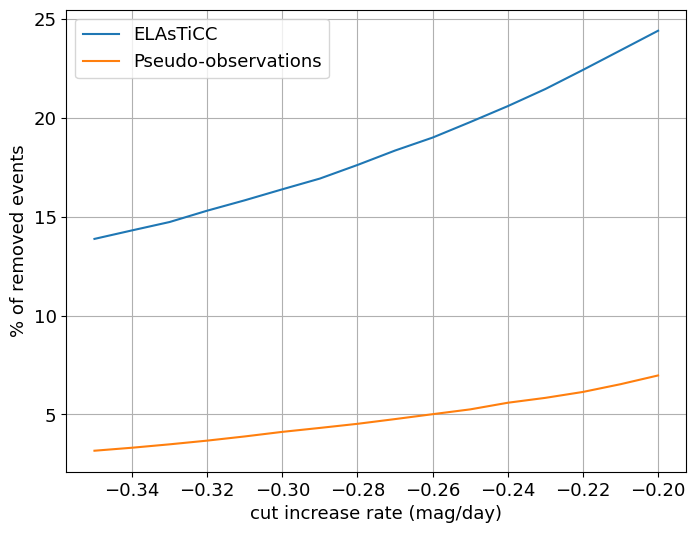

In [27]:
plt.figure(figsize=(8, 6))

cut = np.arange(0.2, 0.36, 0.01)

elasticc = []
po = []

for i in cut:
    
    pdf_cut_i = pdf[(pdf['rate_inc'] > -i)]
    elasticc.append(len(pdf_cut_i[pdf_cut_i['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['rate_inc'])))
    po.append(len(pdf_cut_i[pdf_cut_i['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['rate_inc'])))
    
plt.plot(-cut, (1-np.array(elasticc))*100, label='ELAsTiCC')
plt.plot(-cut, (1-np.array(po))*100, label='Pseudo-observations')
plt.xlabel('cut increase rate (mag/day)')
plt.ylabel('% of removed events')
plt.legend()
plt.grid()

## Cut dt > 25 days

In [28]:
pdf_cut_dt = pdf[(pdf['dt'] < 25)]

In [29]:
# percentage of left events in elasticc data
len(pdf_cut_dt[pdf_cut_dt['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['dt'])) * 100

74.28333837588706

In [30]:
# percentage of left events in pseudo-observations
len(pdf_cut_dt[pdf_cut_dt['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['dt'])) * 100

88.5074128652495

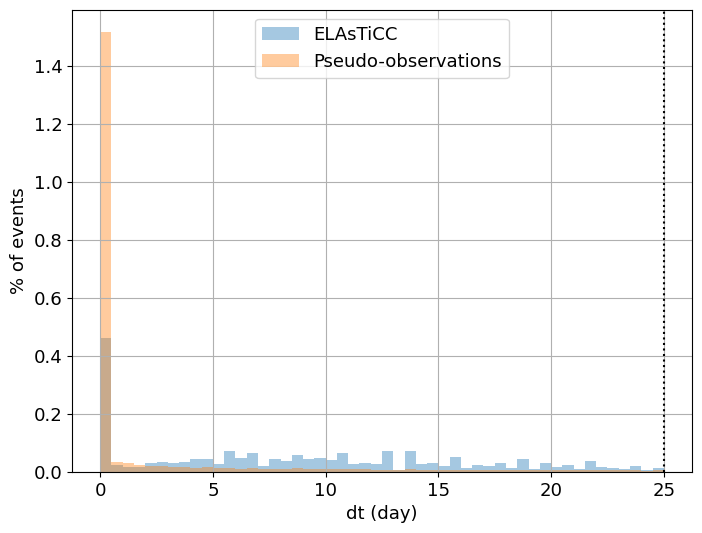

In [31]:
plt.figure(figsize=(8, 6))

pdf_cut_dt['dt'][pdf_cut_dt['type'] == 'elasticc'].hist(bins=50, alpha=0.4, label='ELAsTiCC', density=True);
pdf_cut_dt['dt'][pdf_cut_dt['type'] == 'pseudo-obs'].hist(bins=50, alpha=0.4, label='Pseudo-observations', density=True);

plt.xlabel('dt (day)')
plt.ylabel('% of events')
plt.axvline(x=25, color='k', ls=':')
plt.legend()

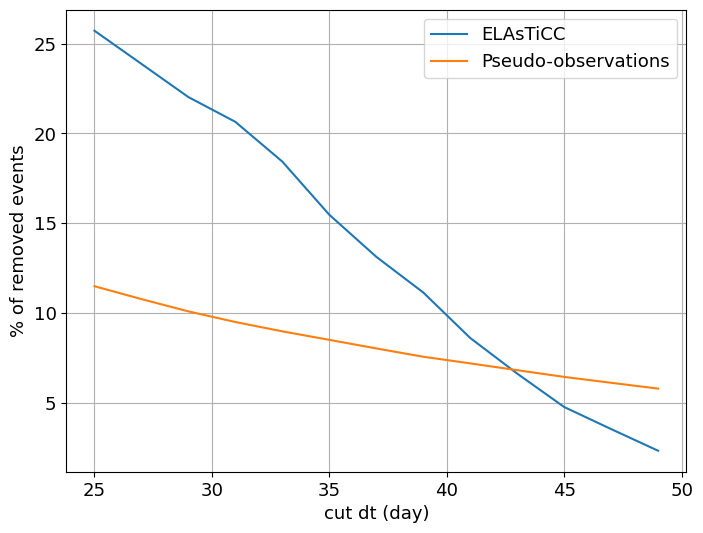

In [32]:
plt.figure(figsize=(8, 6))

cut = np.arange(25, 50, 2)

elasticc = []
po = []

for i in cut:
    
    pdf_cut_dt = pdf[(pdf['dt'] < i)]
    elasticc.append(len(pdf_cut_dt[pdf_cut_dt['type'] == 'elasticc']) / len(pdf_elasticc.dropna(subset=['dt'])))
    po.append(len(pdf_cut_dt[pdf_cut_dt['type'] == 'pseudo-obs']) / len(pdf_po.dropna(subset=['dt'])))
    
plt.plot(cut, (1-np.array(elasticc))*100, label='ELAsTiCC')
plt.plot(cut, (1-np.array(po))*100, label='Pseudo-observations')
plt.xlabel('cut dt (day)')
plt.ylabel('% of removed events')
plt.legend()
plt.grid()